# Problem Statement: Build a Smart Mutual Fund Advisor

*On top of the Mutual Funds Report, [sourced](https://www.kaggle.com/datasets/dhavalrupapara/mutual-funds-market-dataset) from Kaggle*

---

## Objective  
Create a Gradio-based AI assistant that recommends a mutual fund investment portfolio based on the user's risk and return preferences. The app uses Retrieval-Augmented Generation (RAG) on a structured Mutual Fund product dataset, generating explainable, structured results.

---

## User App (Essential Features)

### Inputs
- **Investment Needs**: Free-form text input  
  *(e.g., “high return portfolio, only from Aditya Birla fund house”)*
  
### Output
- **Suggestion**: A natural language explanation of what's recommended and why
- **Recommended Mutual Funds**: Structured as a list containing:
  - Scheme Name
  - Fund House
---

## Developer-Facing Advanced Settings

Shown under a collapsible **LLM Settings (Advanced)** section in the UI.

### Model & Generation Settings
- **Model Selector**: *select 2 more open-source / closed-source models*
  - GPT OSS 120B (`gpt-oss-120b`)
- **Temperature Slider**: Adjustable between 0 and 2

These settings allow developers to tune how deterministic or creative the model’s responses are.

---

## Backend Setup

### Vector Store and RAG
- **Embedding Model**: Nomic Embed Text via Ollama, or other model of your choice
- **Vector Database**: ChromaDB, or other vector DB of your choice
- **RAG Workflow**:
  1. Load product catalog using `CSVLoader`
  2. Parse and clean fields into `Document` objects with metadata
  3. Generate embeddings and index documents
  4. Perform similarity search based on user preferences
  5. Use an LLM to generate structured output parsed via `PydanticOutputParser`

# Part 1: Implement the Solution

## Setup

In [1]:
import gradio as gr
import pandas as pd
import os
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_tavily import TavilySearch
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.output_parsers import PydanticOutputParser
from langchain.schema.output_parser import OutputParserException
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from uuid import uuid4
from langgraph.graph import START, StateGraph, END
from typing_extensions import List, TypedDict
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

os.environ["GROQ_API_KEY"] = GROQ_API_KEY or ""


## Defining Components

### Chat Model

In [ ]:
model_name_map = {
    "GPT-OSS-120B": "openai/gpt-oss-120b",
    "Llama-3.3-70B": "llama-3.3-70b-versatile",
    "GPT-4o-Mini": "gpt-4o-mini"
}

model_choices = [
    "GPT-OSS-120B (Groq)",
    "Llama-3.3-70B (Groq)",
    "GPT-4o-Mini (OpenAI)"
]


In [ ]:
def get_llm(model_choice, temperature):
    if "Groq" in model_choice:
        return init_chat_model(model_name_map[model_choice.split(" ")[0]], model_provider="groq", temperature = temperature)
    elif "OpenAI" in model_choice:
        return init_chat_model(model_name_map[model_choice.split(" ")[0]], model_provider="openai", temperature = temperature)
    else:
        raise ValueError("Invalid model")


### Embedding Model

In [ ]:
import ollama as ollama_client
from langchain_core.embeddings import Embeddings

class ReliableOllamaEmbeddings(Embeddings):
    def __init__(self, model="nomic-embed-text", host="http://localhost:11434"):
        self.model = model
        self.client = ollama_client.Client(host=host)

    def embed_documents(self, texts):
        return [self.client.embeddings(model=self.model, prompt=t)["embedding"] for t in texts]

    def embed_query(self, text):
        return self.client.embeddings(model=self.model, prompt=text)["embedding"]

embeddings = ReliableOllamaEmbeddings(model="nomic-embed-text", host="http://localhost:11434")

### Vector Store

In [ ]:
vector_store = Chroma(
    collection_name="mutual_funds",
    embedding_function=embeddings,
    persist_directory="./chroma_mutual_funds_db"
)


## Load and Preprocess Data

In [ ]:
loader = CSVLoader(file_path="mutual_funds_data.csv", source_column="scheme_code")
documents_raw = loader.load()

In [ ]:
documents = []
for doc in documents_raw:
    try:
        row_data = dict(
            line.split(":", 1) for line in doc.page_content.split("\n") if ":" in line
        )
        row_data = {k.strip(): v.strip() for k, v in row_data.items()}

        page_text = f"""
        Scheme Name: {row_data.get('scheme_name', '')} | 
        Fund House: {row_data.get('fund_house', '')} | 
        Scheme Type: {row_data.get('scheme_type', '')} | 
        Scheme Category: {row_data.get('scheme_category', '')} | 
        Net Asset Value: {row_data.get('net_asset_value', '')} | 
        Date: {row_data.get('date', '')}
        """

        metadata = {
            "Scheme Type": row_data.get("scheme_type", ""),
            "Scheme Category": row_data.get("scheme_category", "")
        }

        documents.append(Document(page_content=page_text, metadata=metadata))

    except Exception as e:
        print("Skipping row due to error:", e)


In [42]:
len(documents)

35559

In [43]:
print(documents[0].page_content)


        Scheme Name: Grindlays Super Saver Income Fund-GSSIF-Half Yearly Dividend | 
        Fund House: Standard Chartered Mutual Fund | 
        Scheme Type: Open Ended Schemes | 
        Scheme Category: Income | 
        Net Asset Value: 10.7205 | 
        Date: 29-05-2008
        


In [44]:
len(documents)

35559

## Store in Vector DB

In [ ]:
documents_to_store = documents[:1000]
uuids = [str(uuid4()) for _ in range(len(documents_to_store))]

vector_store.add_documents(documents=documents_to_store, ids=uuids)


['f3ebcefb-3817-41e1-ae6e-ef183db19606',
 'fe874371-3804-4479-9629-9398dc21ce26',
 '69429ff9-edfc-4aff-8850-8affe81c4a9c',
 'fbcb3aa3-03e7-4e3a-a374-852df9cf2cc8',
 '8ebc08ed-1f0f-42f1-8a04-371f067a8d34',
 '71f05839-00a7-4f20-b231-0da7d689e479',
 'cddb4269-a25e-4f1f-a0f6-127ffd189ad4',
 '1566bc29-8815-4954-a44f-dddfb99f487f',
 '3add5feb-7551-4187-bfdd-455af5f59448',
 '08a843de-20a0-4167-b41e-26d717837a21',
 'e8f52489-8c40-4a50-9fee-8295398f4061',
 'df7c1ef3-e57b-44d9-adc1-27bc60b8d073',
 '20a0efe1-573a-4ffe-85e8-a2da7e64f787',
 '395d4776-016f-4f17-a795-f26434ad7997',
 'f3083a4b-ef89-443e-8f06-bd82328833a3',
 'fdf40b9b-6d15-42dc-9e3f-0e84fadc1994',
 'aeb222c9-3c86-4222-924f-4089a57ab5ef',
 'ffdf3a55-c00e-4443-af46-18ce8b02bc31',
 '08b2994c-2998-49b5-b0d5-995f1de8f985',
 '7838bc34-2a89-402f-9e53-afa0b2bd0c5d',
 '03310a26-4ebb-414a-8f8e-6fad8a665187',
 '156d72d5-4a1a-452f-a8f3-201cd2e42e68',
 'c2e50f7d-efd5-47d5-a18e-2433727df0c0',
 'a3af6db6-68a1-4718-a56e-447096c01d64',
 'af39bd41-4b7f-

## Initializing for RAG

### Initialize Retriever

In [ ]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 5})


### Define Pydantic Schema

In [ ]:
class MutualFund(BaseModel):
    scheme_name: str = Field(description="The name of the mutual fund scheme")
    fund_house: str = Field(description="The Asset Management Company (AMC) that manages the fund")
    scheme_type: str = Field(description="The type of the scheme, e.g. Open Ended Schemes, Close Ended Schemes")
    scheme_category: str = Field(description="The category of the scheme, e.g. Income, Growth, Equity, Debt")

class MutualFundOutput(BaseModel):
    reasoning: str = Field(description="A natural language explanation of what is recommended and why, based on the user's stated preferences")
    schemes: List[MutualFund] = Field(description="A list of recommended mutual fund schemes that best match the user's preferences")

parser = PydanticOutputParser(pydantic_object=MutualFundOutput)


### Define Prompt

In [ ]:
template = ChatPromptTemplate.from_template(
    """You are a Smart Mutual Fund Advisor. A user has shared their investment preferences below.
Using ONLY the mutual fund context provided, recommend a diversified portfolio of mutual funds
that best matches the user's preferences.

IMPORTANT: No two selected mutual fund schemes should share the same Fund House AND Scheme Type combination.

User Preferences:
{preferences}

Available Mutual Funds (context):
{context}

{format_instructions}
"""
)


## Creating RAG Pipeline

### Test RAG Pipeline Manually

In [ ]:
preference = "I want a low risk investment portfolio."
context_docs = retriever.invoke(preference)
relevant_text = "\n\n".join(doc.page_content for doc in context_docs)
llm = get_llm("GPT-OSS-120B (Groq)", 0.7)
chain = template | llm | parser 
input_dict = {
    "preferences": preference,
    "context": relevant_text,
    "format_instructions": parser.get_format_instructions()
}
chain.invoke(input_dict)


MutualFundOutput(reasoning='The user wants a low‑risk investment portfolio. All debt‑oriented schemes are generally lower risk than equity funds, so the recommendation focuses on debt schemes. To satisfy the diversification rule (no two funds may share the same Fund House\u202f+\u202fScheme Type pair), only one scheme is selected from each asset‑management company. The three chosen funds – one each from Sundaram Mutual Fund, Franklin Templeton Mutual Fund, and LIC Mutual Fund – are all Open Ended debt schemes, providing a balanced, low‑risk mix while adhering to the constraint.', schemes=[MutualFund(scheme_name='Sundaram Short Term Credit Risk Fund -Dividend', fund_house='Sundaram Mutual Fund', scheme_type='Open Ended Schemes', scheme_category='Debt Scheme - Credit Risk Fund'), MutualFund(scheme_name='Franklin India Low Duration Fund - Quarterly - IDCW', fund_house='Franklin Templeton Mutual Fund', scheme_type='Open Ended Schemes', scheme_category='Debt Scheme - Low Duration Fund'), Mu

### Define RAG Pipeline Function

In [ ]:
# RAG pipeline
def generate_portfolio(model_choice, user_input):
    context_docs = retriever.invoke(user_input["preferences"])
    relevant_funds = "\n\n".join(doc.page_content for doc in context_docs)
    llm = get_llm(model_choice, user_input["temperature"])
    
    #Invoking
    chain = template | llm
    output = chain.invoke({
        "preferences": user_input["preferences"],
        "context": relevant_funds,
        "format_instructions": parser.get_format_instructions()
    })

    #Exception Handling
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None
    return result


## User Interface

In [51]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    result = generate_portfolio(model_choice, user_input)
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [52]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [53]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


# Part 2: Implement the RAG pipeline in LangGraph

## Creating Graph

### Define State Class

In [ ]:
class State(TypedDict):
    preferences: str
    context: List[Document]
    answer: MutualFundOutput


### Define Nodes

In [ ]:
def retrieve(state: State):
    relevant_funds = retriever.invoke(state["preferences"])
    return {"context": relevant_funds}


In [ ]:
def generate(state: State):
    relevant_funds_str = "\n\n".join(doc.page_content for doc in state["context"])
        
    chain = template | llm_graph 
    output = chain.invoke({
        "preferences": state["preferences"],
        "context": relevant_funds_str,
        "format_instructions": parser.get_format_instructions()
    })

    #Exception Handling for Output Parser
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None
        
    return {"answer": result}


### Build and Compile Graph

In [ ]:
graph_builder = StateGraph(State)

graph_builder.add_node("retrieve", retrieve) 
graph_builder.add_node("generate", generate) 

graph_builder.add_edge(START, "retrieve") 
graph_builder.add_edge("retrieve", "generate") 
graph_builder.add_edge("generate", END) 


In [58]:
#Compile graph
graph = graph_builder.compile()

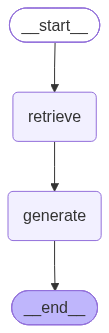

In [59]:
#Visualize graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Test Manually

In [ ]:
preferences = "I want a low risk investment portfolio."
llm_graph = get_llm("GPT-OSS-120B (Groq)", 0.7) 
result = graph.invoke({"preferences": preferences}) 
print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')


Context: [Document(id='4de73dd4-f1f7-4144-9ab3-34077ae39256', metadata={'Scheme Type': 'Open Ended Schemes', 'Scheme Category': 'Debt Scheme - Credit Risk Fund'}, page_content='\n        Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend | \n        Fund House: Sundaram Mutual Fund | \n        Scheme Type: Open Ended Schemes | \n        Scheme Category: Debt Scheme - Credit Risk Fund | \n        Net Asset Value: 11.3002 | \n        Date: 29-12-2020\n        '), Document(id='60deb8f4-bba9-402f-a7b1-b6c507ea2af9', metadata={'Scheme Category': 'Debt Scheme - Low Duration Fund', 'Scheme Type': 'Open Ended Schemes'}, page_content='\n        Scheme Name: Franklin India Low Duration Fund - Quarterly - IDCW | \n        Fund House: Franklin Templeton Mutual Fund | \n        Scheme Type: Open Ended Schemes | \n        Scheme Category: Debt Scheme - Low Duration Fund | \n        Net Asset Value: 14.7667 | \n        Date: 07-08-2022\n        '), Document(id='fdc45271-7c94-4644-aa1c-4a197e

## User Interface

In [61]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    llm_graph = get_llm(user_input["model_choice"], user_input["temperature"])
    result = graph.invoke({"preferences": preferences})["answer"]
    
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [62]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [63]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
